In [ ]:
# Deep Learning Optimization: MLflow & Optuna (TensorFlow)

# Phase 1: Environment Setup & Exploratory Data Analysis
# We initialize the required frameworks for Deep Learning (TensorFlow), Experiment Tracking (MLflow), and Hyperparameter Optimization (Optuna). 
# Following this, we load and explore the California Housing dataset.

In [1]:
# --- 1. Core Libraries & MLflow/Optuna Imports ---

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import mlflow
import mlflow.tensorflow
import optuna
import logging
import warnings

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras import Input
from tensorflow.keras.layers import LeakyReLU, Activation, Input
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# --- 2. Data Loading & Exploratory Data Analysis ---

california = fetch_california_housing(as_frame=True)
df = california.frame  # pandas DataFrame

print("Форма даних:", df.shape)
print("Назви ознак:", df.columns.tolist())

print("Кількість пропусків у стовпцях:")
print(df.isnull().sum())

display(df.head())

display(df.describe())

Форма даних: (20640, 9)
Назви ознак: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']
Кількість пропусків у стовпцях:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


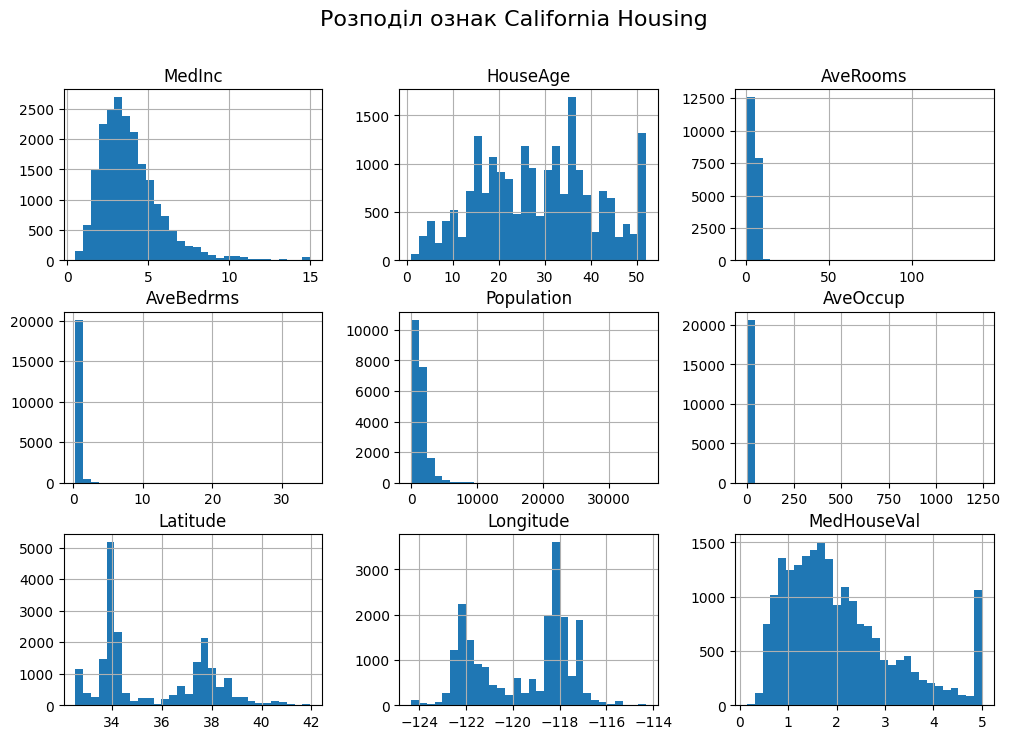

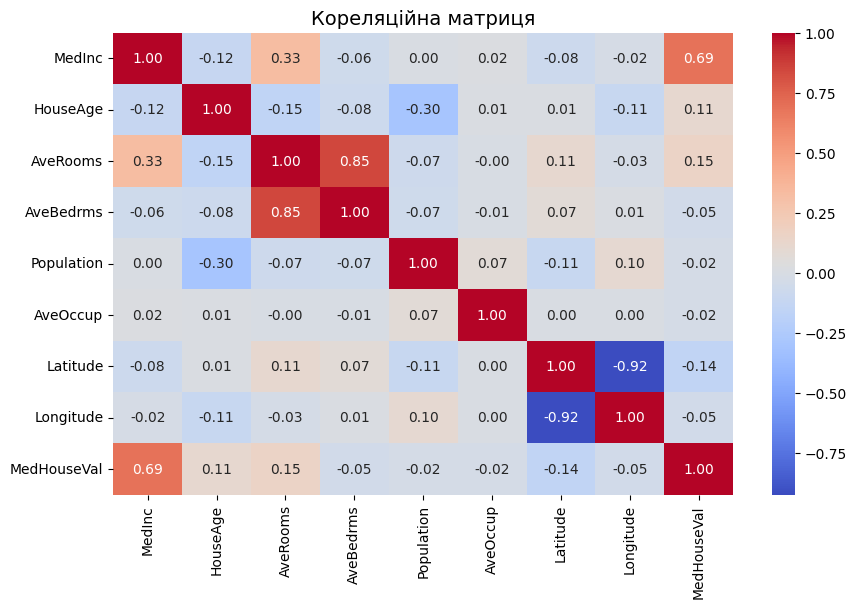

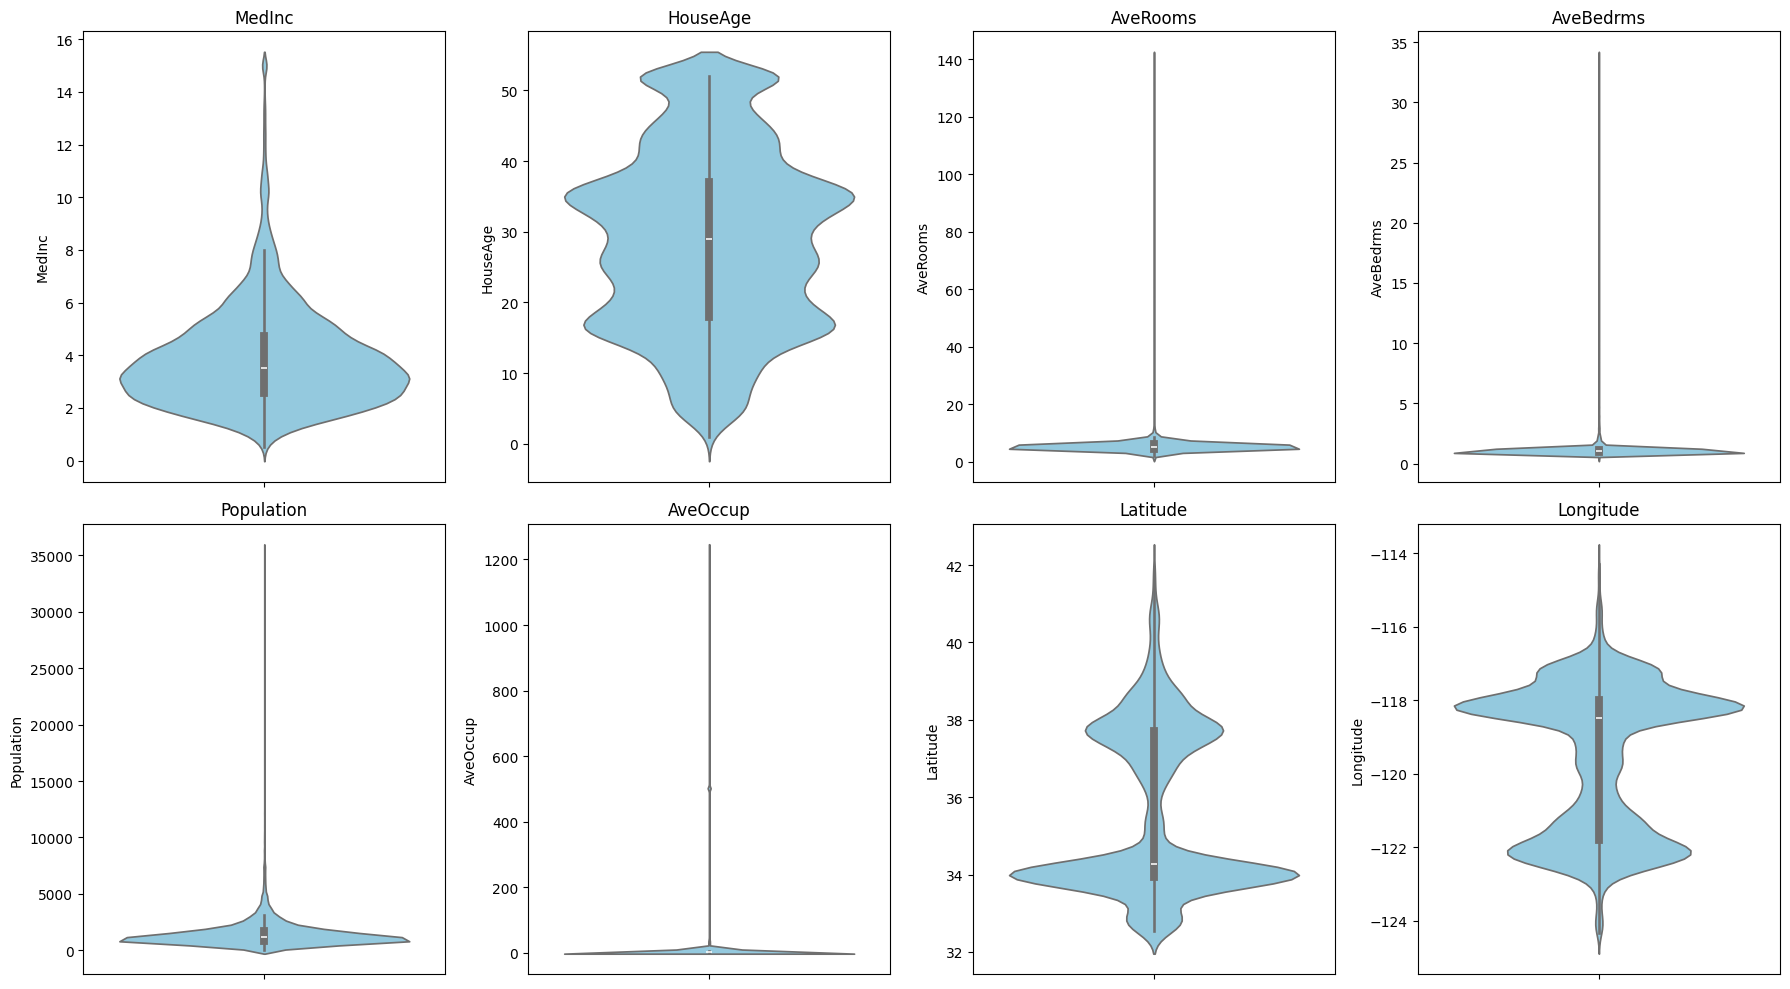

In [3]:
# --- 3. Data Visualization ---

# Feature Distributions
df.hist(figsize=(12, 8), bins=30)
plt.suptitle("Розподіл ознак California Housing", fontsize=16)
plt.show()

# Correlation Matrix
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляційна матриця", fontsize=14)
plt.show()

# Violin Plots for Feature Spread
features = df.columns.drop("MedHouseVal")
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()  # 1D масив
for ax, col in zip(axes, features):
    sns.violinplot(y=df[col], ax=ax, inner="box", color="skyblue")
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [ ]:
# Phase 2: Data Preprocessing & Architectures Definition
# We split the dataset and apply Standard Scaling alongside Principal Component Analysis (PCA) to reduce dimensionality. 
# Then, we define the baseline and advanced neural network architectures to test different activation functions and regularization techniques.

In [4]:
# 4. Поділ даних

# --- 4. Data Splitting ---
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"].to_numpy()

# Train (70%), Validation (15%), Test (15%) Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("--- Dataset Splits ---")
print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val: {X_val.shape}, {y_val.shape}")
print(f"Test: {X_test.shape}, {y_test.shape}\n")

Розміри вибірок:
Train: (14448, 8) (14448,)
Val: (3096, 8) (3096,)
Test: (3096, 8) (3096,)


Explained variance ratio (5 components): [0.25332065 0.23393326 0.15935984 0.12964566 0.12550435]
Total variance explained: 0.901763752448135


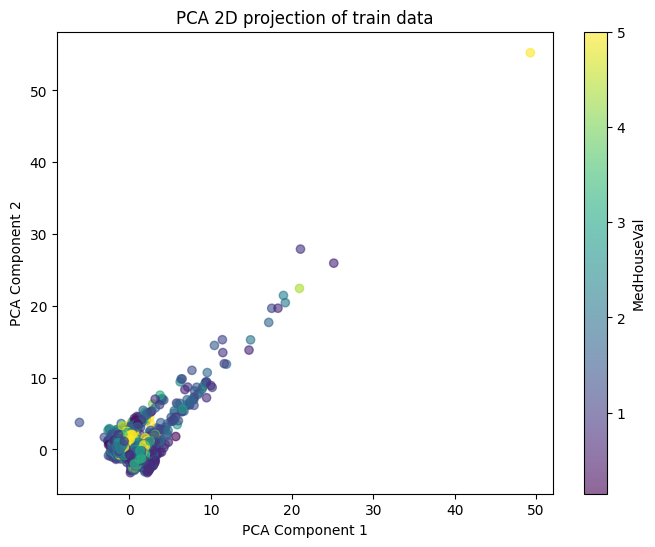

In [5]:
# --- 5. Scaling & Dimensionality Reduction (PCA) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"PCA Explained variance ratio (5 components): {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.4f}")

plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(label='MedHouseVal')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('2D PCA projection of training data')
plt.show()

In [6]:
# --- 6. Architecture Demonstration ---
input_dim = X_train_pca.shape[1]

# Baseline Feedforward Network
model_basic = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(1)
])

# Advanced Network (Dropout, BatchNorm, L2)
model_advanced = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)),
    Dense(1)
])

models_summary = {"Baseline Network": model_basic, "Advanced Network": model_advanced}

for name, model in models_summary.items():
    print(f"\n{'='*40}\n{name}:\n{'='*40}")
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    model.summary()


Базова мережа:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,497 (9.75 KB)

...

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │             768 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,905 (46.50 KB)

 Trainable params: 11,521 (45.00 KB)

 Non-trainable params: 384 (1.50 KB)

In [7]:
# --- 7. Model Compilations for Experimentation ---

# Baseline with ReLU
model_basic_relu = Sequential([
    Input(shape=(input_dim,)),
    Dense(64, activation='relu'), Dense(32, activation='relu'), Dense(1)
])
model_basic_relu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Baseline with LeakyReLU
model_basic_leaky = Sequential([
    Input(shape=(input_dim,)),
    Dense(64), LeakyReLU(negative_slope=0.1),
    Dense(32), LeakyReLU(negative_slope=0.1), Dense(1)
])
model_basic_leaky.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Advanced with ReLU
model_adv_relu = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, activation='relu', kernel_regularizer=l2(0.001)), BatchNormalization(), Dropout(0.3),
    Dense(64, activation='relu', kernel_regularizer=l2(0.001)), BatchNormalization(), Dropout(0.3),
    Dense(32, activation='relu', kernel_regularizer=l2(0.001)), Dense(1)
])
model_adv_relu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

# Advanced with GELU
model_adv_gelu = Sequential([
    Input(shape=(input_dim,)),
    Dense(128, kernel_regularizer=l2(0.001)), Activation(tf.nn.gelu), BatchNormalization(), Dropout(0.3),
    Dense(64, kernel_regularizer=l2(0.001)), Activation(tf.nn.gelu), BatchNormalization(), Dropout(0.3),
    Dense(32, kernel_regularizer=l2(0.001)), Activation(tf.nn.gelu), Dense(1)
])
model_adv_gelu.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

In [ ]:
# Phase 3: MLflow Experiment Tracking & Optuna Optimization
# We utilize MLflow to systematically track the training runs, logging parameters, metrics, and models. 
# Subsequently, we deploy Optuna to perform an automated hyperparameter search to discover the optimal network architecture dynamically.

In [8]:
# --- 8. Model Training with MLflow Tracking ---
# Suppress third-party warnings for clean output
logging.getLogger("absl").setLevel(logging.ERROR)
logging.getLogger("mlflow").setLevel(logging.ERROR)
warnings.filterwarnings("ignore", category=FutureWarning)

mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("Lab1_California_Housing_TF")
mlflow.tensorflow.autolog()

epochs, batch_size = 15, 32
histories = {}
models_to_train = {
    "Basic_ReLU": model_basic_relu,
    "Basic_LeakyReLU": model_basic_leaky,
    "Advanced_ReLU": model_adv_relu,
    "Advanced_GELU": model_adv_gelu
}

print("--- Initiating MLflow Training Runs ---")
for name, model in models_to_train.items():
    print(f"Training Architecture: {name}...")
    with mlflow.start_run(run_name=name):
        history = model.fit(
            X_train_pca, y_train,
            validation_data=(X_val_pca, y_val),
            epochs=epochs, batch_size=batch_size, verbose=0 
        )
        histories[name] = history
        test_loss, test_mae = model.evaluate(X_test_pca, y_test, verbose=0)
        mlflow.log_metric("test_mse", test_loss)
print("✅ Training sequence completed!")

--- Початок навчання ---
Навчання: Basic_ReLU...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Навчання: Basic_LeakyReLU...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Навчання: Advanced_ReLU...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Навчання: Advanced_GELU...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Навчання завершено!


In [9]:
# --- 9. Architecture Optimization via Optuna ---
# Restrict Optuna and TF logging to actual errors only
optuna.logging.set_verbosity(optuna.logging.WARNING)
tf.get_logger().setLevel('ERROR')

def objective(trial):
    tf.keras.backend.clear_session() # Prevent memory leaks
    
    n_layers = trial.suggest_int("n_layers", 1, 3)
    activation = trial.suggest_categorical("activation", ["relu", "gelu"])
    dropout_rate = trial.suggest_float("dropout_rate", 0.0, 0.3)
    
    model = Sequential()
    model.add(Input(shape=(input_dim,)))
    
    for i in range(n_layers):
        num_units = trial.suggest_int(f"n_units_l{i}", 32, 128)
        model.add(Dense(num_units, kernel_regularizer=l2(0.001)))
        model.add(Activation("relu") if activation == "relu" else Activation(tf.nn.gelu))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))
        
    model.add(Dense(1))
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    
    history = model.fit(X_train_pca, y_train, validation_data=(X_val_pca, y_val), epochs=15, batch_size=32, verbose=0)
    return history.history['val_loss'][-1]

print("\n--- Executing Optuna Hyperparameter Search ---")
study = optuna.create_study(direction="minimize", study_name="TF_Architecture_Opt")
study.optimize(objective, n_trials=50)

print(f"\nBest Validation MSE Achieved: {study.best_value:.4f}")
print(f"Optimal Parameters: {study.best_params}")

with mlflow.start_run(run_name="Optuna_Best_Model"):
    mlflow.log_params(study.best_params)
    mlflow.log_metric("best_val_mse", study.best_value)

Пошук оптимальної архітектури...


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step


...

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

Найкращий Validation MSE: 0.5923
Найкращі параметри: {'n_layers': 1, 'activation': 'relu', 'dropout_rate': 0.014307609209900915, 'n_units_l0': 78}


In [ ]:
# Phase 4: Learning Curves & Comprehensive Metrics
# We visualize the training progress across all predefined architectures to monitor for convergence and overfitting. 
# Finally, we calculate and display rigorous evaluation metrics (MAE, MSE, RMSE, R²) for all data splits.

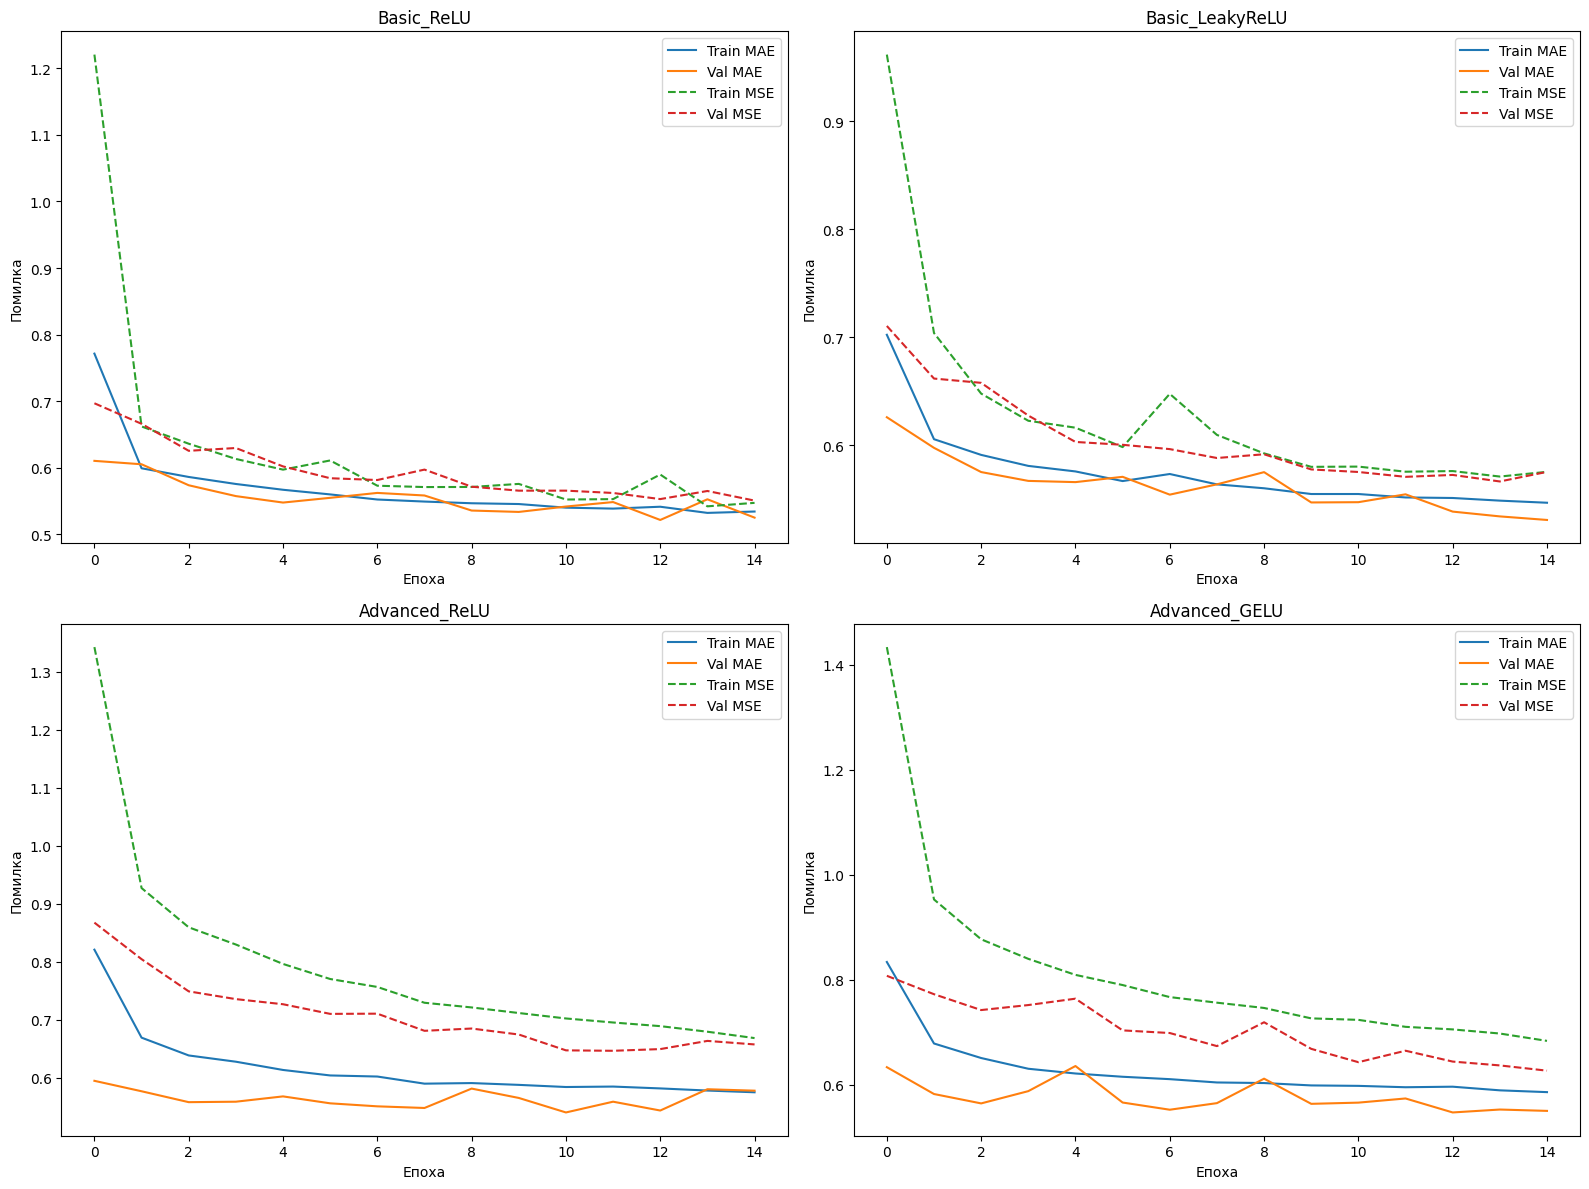

In [12]:
# --- 10. Learning Curves Visualization ---
plt.figure(figsize=(16, 12))

for i, (name, model) in enumerate(models_to_train.items(), 1):
    history = histories[name]
    plt.subplot(2, 2, i)
    plt.plot(history.history['mae'], label='Train MAE', color='blue')
    plt.plot(history.history['val_mae'], label='Val MAE', color='orange')
    plt.plot(history.history['loss'], '--', label='Train MSE (Loss)', color='green')
    plt.plot(history.history['val_loss'], '--', label='Val MSE', color='red')
    plt.title(f"Learning Curves: {name}")
    plt.xlabel('Epochs')
    plt.ylabel('Error Margin')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# --- 11. Comprehensive Model Evaluation Metrics ---
print("=== Final Metrics Overview ===\n")

for name, model in models_to_train.items():
    # Generate predictions (silently)
    y_train_pred = model.predict(X_train_pca, verbose=0).ravel()
    y_val_pred = model.predict(X_val_pca, verbose=0).ravel()
    y_test_pred = model.predict(X_test_pca, verbose=0).ravel()
    
    # Calculate metrics
    metrics = {}
    for split_name, y_true, y_pred in zip(
        ["Train", "Validation", "Test"],
        [y_train, y_val, y_test],
        [y_train_pred, y_val_pred, y_test_pred]
    ):
        mae = mean_absolute_error(y_true, y_pred)
        mse = mean_squared_error(y_true, y_pred)
        rmse_val = np.sqrt(mse)
        r2 = r2_score(y_true, y_pred)
        metrics[split_name] = (mae, mse, rmse_val, r2)
    
    # Display Output
    print(f"Architecture: {name}")
    for split_name in ["Train", "Validation", "Test"]:
        mae, mse, rmse_val, r2 = metrics[split_name]
        print(f"  {split_name:<10} | MAE={mae:.4f}, MSE={mse:.4f}, RMSE={rmse_val:.4f}, R²={r2:.4f}")
    print("-" * 70)

Метрики для моделей:

Модель: Basic_ReLU
  Train: MAE=0.5266, MSE=0.5374, RMSE=0.7331, R²=0.5989
  Validation: MAE=0.5252, MSE=0.5508, RMSE=0.7422, R²=0.5772
  Test: MAE=0.5184, MSE=0.5242, RMSE=0.7240, R²=0.6036
------------------------------------------------------------
Модель: Basic_LeakyReLU
  Train: MAE=0.5333, MSE=0.5667, RMSE=0.7528, R²=0.5770
  Validation: MAE=0.5307, MSE=0.5752, RMSE=0.7584, R²=0.5585
  Test: MAE=0.5258, MSE=0.5530, RMSE=0.7436, R²=0.5818
------------------------------------------------------------
Модель: Advanced_ReLU
  Train: MAE=0.5757, MSE=0.5933, RMSE=0.7703, R²=0.5571
  Validation: MAE=0.5779, MSE=0.6076, RMSE=0.7795, R²=0.5336
  Test: MAE=0.5685, MSE=0.5743, RMSE=0.7579, R²=0.5656
------------------------------------------------------------
Модель: Advanced_GELU
  Train: MAE=0.5488, MSE=0.5653, RMSE=0.7518, R²=0.5781
  Validation: MAE=0.5505, MSE=0.5799, RMSE=0.7615, R²=0.5549
  Test: MAE=0.5403, MSE=0.5462, RMSE=0.7391, R²=0.5869
--------------------